# Simulator

In [2]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import pandas as pd

## Definition of System Parameters

### Cost Parameters

In [3]:
cost_failure = 1200
cost_component = 100
cost_inspection = 100
cost_replacement = 1000

### Model Parameters

Define the parameters $\eta = 30*24 h$, one month, $\beta = 3$ for the components "Fail Age" given by a Weibull distribution.

Define the expiration age as $110\%$ of $\mu$ for the automatic mandatory component replacement, despite inspections. 

In [4]:
eta = 30*24
beta = 3

expiration = 1.1*eta

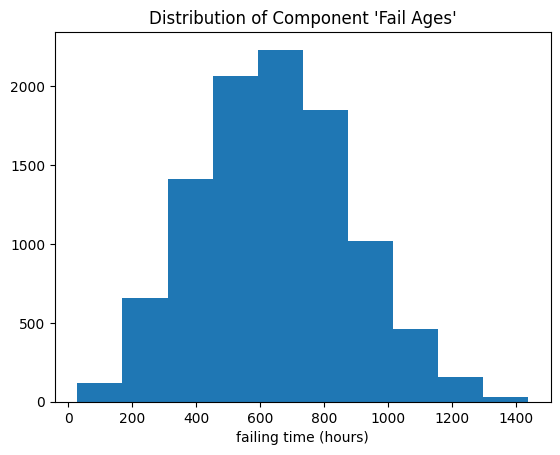

In [5]:
fail_ages = eta*np.random.weibull(beta, size=10000)

plt.hist(fail_ages)
plt.xlabel("failing time (hours)")
plt.title("Distribution of Component 'Fail Ages'")
plt.show()

### Inspection Schedule Parameters

Define the parameters $\mu = 7*24 h$, one week, $\sigma = 15\%$ of $ \mu$ for the time between inspections, given by a Normal distribution.

Also, when an inspection is required but not urgent, the time for said inspectin is scheduled following an Exponential distribution of parameter $\theta = 12h$

In [6]:
mu = 7*24
sigma = 0.15*mu

theta = 12

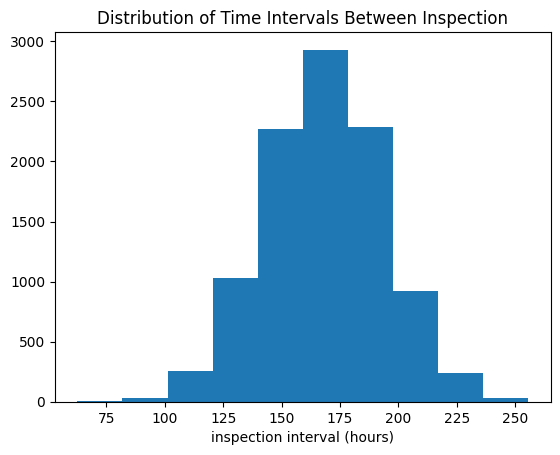

In [7]:
inspection_windows = np.random.normal(loc=mu, scale=sigma, size=10000)

plt.hist(inspection_windows)
plt.xlabel("inspection interval (hours)")
plt.title("Distribution of Time Intervals Between Inspection")
plt.show()

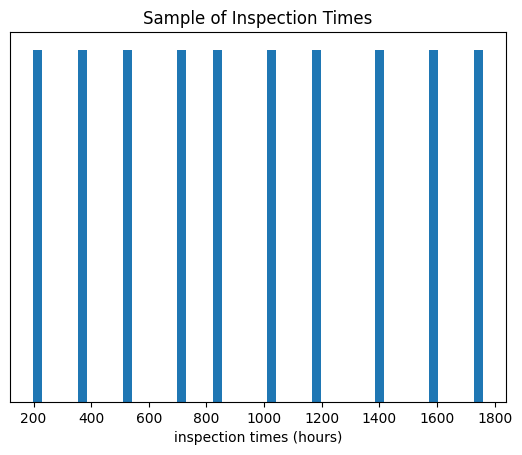

In [8]:
inspection_times = np.cumsum(inspection_windows)[:10]

plt.hist(inspection_times, bins=50)
plt.xlabel("inspection times (hours)")
plt.yticks([])
plt.title("Sample of Inspection Times")
plt.show()

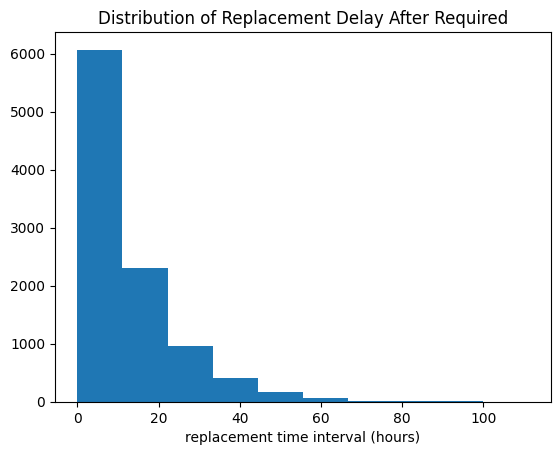

In [63]:
inspection_windows = np.random.exponential(theta, size=10000)

plt.hist(inspection_windows)
plt.xlabel("replacement time interval (hours)")
plt.title("Distribution of Replacement Delay After Required")
plt.show()

### Inspection Quality Parameters

The objective of an inspection is to check if a component is old, that can be seen as presenting wearing signals. Since the age of a component is known, but not exactly its distribution, we model this fenomenon as follows:
 * A measure of the age/wear of a component will be an estimation the CDF (Cumulated Density Function) if its fail age; if the pdf is close the 0 the component is new, and if it is close to 1, it almost centainly will present a pane
 * Since the inspection is not perfect, we consider a distribution around the exact CDF in question; this is done by considering a Beta distribution whose average is the exact CDF, $Mean = CDF(component)$ and variance given by $Var = \alpha* Mean*(1-Mean)$, where $0 < \alpha < 1$ is a quality measure, this is due to a known constraint that in a Beta distribution the variance is required to be inferior to $Mean*(1-Mean)$.
 * The parameters $a,b$ of the Beta distribution are finally given as follows, based on: $a =  CDF* (CDF*(1-CDF)/VAR-1)$ and $b = (1-CDF)*(CDF*(1-CDF)/VAR-1)$. See https://en.wikipedia.org/wiki/Beta_distribution#Mean_and_variance for clarification

In [9]:
inspection_threshold = 0.5
inspection_deviation = 0.05

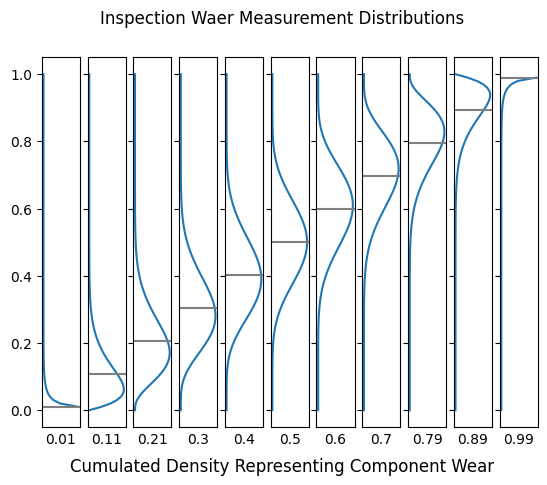

In [10]:
n = 11
fig, ax = plt.subplots(1, n, sharey=True)

cdfs = np.linspace(0.01,0.99,n)

sample = np.linspace(0,1,100)
for i in range(n):
    age_cdf = cdfs[i]

    var = inspection_deviation*age_cdf*(1-age_cdf)
    a = age_cdf * (age_cdf*(1-age_cdf)/var-1)
    b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
    
    pdf = scp.stats.beta.pdf(sample, a, b)

    ax[i].plot(pdf, sample)
    ax[i].axhline(y=age_cdf, color="gray")
    ax[i].set_xlabel(age_cdf.round(2))
    ax[i].set_xticks([])

plt.suptitle("Inspection Waer Measurement Distributions")
fig.supxlabel("Cumulated Density Representing Component Wear")
plt.show()

### Simulate

We show an example of how to use the simulator implemented in the package `simmcm2d` to obtain samples. Do not forget to have the library in question installed in order to run the following.

In [11]:
from simmcm2d import sample_datasets, sample_datasets_conf

In [12]:
param = {
    "eta":eta,
    "beta":beta,
    "expiration":expiration,

    "mu":mu,
    "sigma":sigma,
    "theta":theta,
    "inspection_deviation":inspection_deviation,
    "inspection_threshold":inspection_threshold,
}

costs = {
    "replacement":cost_replacement,
    "inspection":cost_inspection,
    "component":cost_component,
    "failure":cost_failure
}

conf = {
    "param":param,
    "costs":costs,
    "n_systems":10,
    "n_events":10000,
    "time_origin":0,
    "id_0_component":0,
    "id_0_system":0
}

In [13]:
#df = sample_datasets(**conf)
df = sample_datasets(param, costs, n_systems = 10, n_events = 10000,
                     time_origin=0, id_0_component=0, id_0_system=0)

df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,9,9,1970-01-06,11:40:51,inspection,None,131.68,131.68,131.68,None,100,100
1,10,10,1970-01-07,00:40:16,inspection,None,144.67,144.67,144.67,None,100,100
2,4,4,1970-01-07,09:44:29,inspection,None,153.74,153.74,153.74,None,100,100
3,1,1,1970-01-07,14:13:27,inspection,None,158.22,158.22,158.22,None,100,100
4,3,3,1970-01-07,15:22:28,inspection,None,159.37,159.37,159.37,None,100,100


Calcul des différents KPI

1. Nombre de pannes


In [14]:
df['event_date'] = pd.to_datetime(df['event_date'])

nb_pannes = np.sum(df["event_type"] == "failure")
nb_inspections = len(df[df['event_type'] == 'inspection'])
nb_remplacements = len(df)-nb_inspections-nb_pannes

In [15]:
# Number of failure per month

failures = df[df.event_type == "failure"]
failures = df[df.event_type == "failure"].copy()
failures['month'] = failures['event_date'].dt.to_period("M")

monthly_failures = failures.groupby("month").size()
monthly_failures.describe()

# Number of failure per trimestre

failures = df[df.event_type == "failure"]
failures = df[df.event_type == "failure"].copy()
failures['trimestre'] = failures['event_date'].dt.to_period("Q")

trimestre_failures = failures.groupby("trimestre").size()
trimestre_failures.describe()

# Number of failure per year

failures = df[df.event_type == "failure"]
failures = df[df.event_type == "failure"].copy()
failures['year'] = failures['event_date'].dt.to_period("Y")

year_failures = failures.groupby("year").size()
year_failures.describe()


count     13.000000
mean      97.923077
std        5.722201
min       89.000000
25%       94.000000
50%       98.000000
75%      100.000000
max      107.000000
dtype: float64

In [17]:
# Number of reparation per months

replacement = df[df.event_type == "replacement"]
replacement = df[df.event_type == "replacement"].copy()
replacement['month'] = replacement['event_date'].dt.to_period("M")

monthly_replacement = replacement.groupby("month").size()
monthly_replacement.describe()

# Number of reparation per trimestre

replacement = df[df.event_type == "replacement"]
replacement = df[df.event_type == "replacement"].copy()
replacement['trimestre'] = replacement['event_date'].dt.to_period("Q")

trimestre_replacement = replacement.groupby("trimestre").size()
trimestre_replacement.describe()

# Number of reparation per year

replacement = df[df.event_type == "replacement"]
replacement = df[df.event_type == "replacement"].copy()
replacement['year'] = replacement['event_date'].dt.to_period("Y")

year_replacement = replacement.groupby("year").size()
year_replacement.describe()

count     13.000000
mean     156.615385
std        6.474803
min      144.000000
25%      153.000000
50%      156.000000
75%      160.000000
max      169.000000
dtype: float64

Each time the average of replacement is higher than the average of failure. This is a good point, it means that the inspection is useful.

In [18]:
# Ratio (it's the same ratio for month, trimestre and year)

monthly_ratio = monthly_replacement.describe()["mean"] / monthly_failures.describe()["mean"]
monthly_ratio

trimestre_ratio = trimestre_replacement.describe()["mean"] / trimestre_failures.describe()["mean"]
trimestre_ratio

year_ratio = year_replacement.describe()["mean"] / year_failures.describe()["mean"]
year_ratio

1.5993715632364494

2. Qualité du détecteur

In [19]:
detections = len(df[df['FF'] == 'True'])
fausses_alertes = len(df[df['FF'] == 'False'])
precision = detections / (detections + fausses_alertes) if (detections + fausses_alertes) > 0 else 0
rappel = detections / (detections + nb_pannes) if (detections + nb_pannes) > 0 else 0

3. Costs

In [20]:
df['cost_event'] = df['event_type'].map(costs)

cost_per_system = df.groupby('system_id')['cost_cumulated'].last().reset_index()
print(cost_per_system)
print(cost_per_system['cost_cumulated'].describe())

   system_id  cost_cumulated
0          1          459000
1          2          421500
2          3          429700
3          4          440100
4          5          453100
5          6          444300
6          7          452900
7          8          440800
8          9          436400
9         10          444600
count        10.000000
mean     442240.000000
std       11306.065236
min      421500.000000
25%      437325.000000
50%      442550.000000
75%      450825.000000
max      459000.000000
Name: cost_cumulated, dtype: float64


KPI's Dictionary

In [21]:
KPI = {
    "Average of failure per month": monthly_failures.describe()["mean"],
    "Average of failure per trimestre": trimestre_failures.describe()["mean"],
    "Average of failure per year":year_failures.describe()["mean"],
    "Stability per month":monthly_failures.describe()["std"],
    "Stability per trimestre":trimestre_failures.describe()["std"],
    "Stability per year":year_failures.describe()["std"],
    "Preventive Effectiveness Ratio (PER)": monthly_ratio,
    
    "Précision du détecteur": round(precision, 2),
    "Taux de détection (Rappel)": round(rappel, 2),
    
    "Average cost of one system": cost_per_system['cost_cumulated'].describe()["mean"],
    "Standard Deviation": cost_per_system['cost_cumulated'].describe()["std"]
}

In [22]:
KPI

{'Average of failure per month': 8.212903225806452,
 'Average of failure per trimestre': 24.48076923076923,
 'Average of failure per year': 97.92307692307692,
 'Stability per month': 2.051249529782051,
 'Stability per trimestre': 3.8424378730756934,
 'Stability per year': 5.722201477018242,
 'Preventive Effectiveness Ratio (PER)': 1.5993715632364494,
 'Précision du détecteur': 0,
 'Taux de détection (Rappel)': 0.0,
 'Average cost of one system': 442240.0,
 'Standard Deviation': 11306.065235576483}

### Using Json Configuration

Alternative to the previous direct call, one can take advantage of using a `.json` configuration file as follows, by reading the configuration file and passng directly the parameters, or by using the specific function:

In [24]:
conf_filepath = "sample_system_dataset.json"

df = sample_datasets_conf(conf_filepath)
df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,10,10,1970-01-03,10:58:32,failure,None,58.98,58.98,58.98,None,1200,1200
1,10,10,1970-01-03,10:58:32,replacement,unused,58.98,58.98,0.00,None,1100,2300
2,4,4,1970-01-06,02:17:00,inspection,None,122.28,122.28,122.28,None,100,100
3,2,2,1970-01-07,13:52:43,inspection,None,157.88,157.88,157.88,None,100,100
4,1,1,1970-01-07,14:38:57,inspection,None,158.65,158.65,158.65,None,100,100


### Saving to Outputs Files

If the parameters implement the fields:
 * `output_data_filepath` - used to save the dataframe generated
 * `output_table_filepath` - used to save/reunite the parameters used
 
the speficied filepath are used to save the relevant data:

In [33]:
conf["output_data_filepath"] = "sample_system_dataset_1.csv"
conf["output_table_filepath"] = "sample_system_datatable.csv"

In [34]:
df = sample_datasets(**conf)
df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,2,2,1970-01-06,05:37:22,inspection,NaN,125.62,125.62,125.62,None,100,100
1,3,3,1970-01-06,12:49:35,inspection,NaN,132.83,132.83,132.83,None,100,100
2,8,8,1970-01-06,22:43:37,inspection,NaN,142.73,142.73,142.73,None,100,100
3,5,5,1970-01-07,04:28:22,inspection,NaN,148.47,148.47,148.47,None,100,100
4,6,6,1970-01-07,06:10:21,inspection,NaN,150.17,150.17,150.17,None,100,100


### Observe the distribution of fail ages

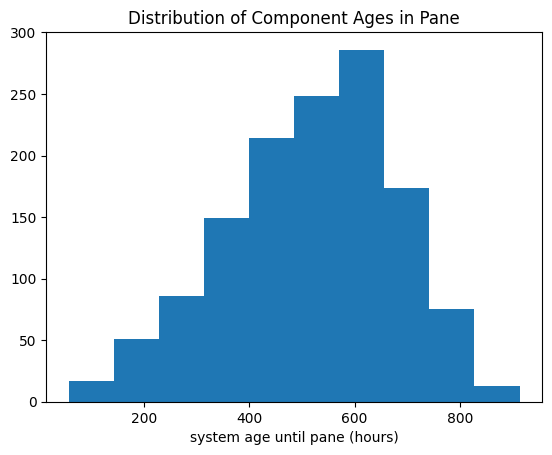

In [26]:
plt.hist(df[df.event_type=="failure"].component_age)
plt.xlabel("system age until pane (hours)")
plt.title("Distribution of Component Ages in Pane")
plt.show()

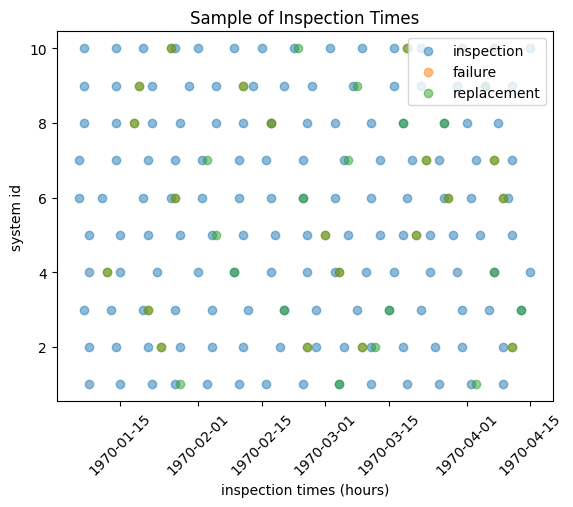

In [27]:
n_events_show = 200
for e_type in df.event_type.unique():
    df_ = df[:n_events_show]
    df_ = df_[df_.event_type == e_type]
    plt.scatter(df_.event_date,
                df_.system_id,
                label=e_type,
                alpha=0.5)

plt.legend()
plt.xlabel("inspection times (hours)")
plt.ylabel("system id")
plt.xticks(rotation=45)
plt.title("Sample of Inspection Times")
plt.show()